**1. Objective & Modeling Strategy**

• **Objective:**
Train and compare multiple classification models
to predict student employability risk.

• **Approach:**
- Baseline linear model
- Tree-based ensemble model
- Performance comparison using robust evaluation metrics

**2. Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

**3. Load Datase**t

In [2]:
df = pd.read_csv("/content/sample_data/employability_prediction_data.csv")

X = df.drop("Employable", axis=1)
y = df["Employable"]

**4. Train-Test Split**

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**5. Load Scaler & Scale Data**

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

**6. Model 1: Logistic Regression (Baseline)**

In [6]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

**7. Model 2: Random Forest (Non-Linear Benchmark)**

In [7]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

**8. Evaluation Function**

In [8]:
def evaluate_model(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

**9. Compare Model Performance**

In [9]:
results_log = evaluate_model(y_test, y_pred_log, y_prob_log)
results_rf = evaluate_model(y_test, y_pred_rf, y_prob_rf)

results_df = pd.DataFrame([results_log, results_rf],
                          index=["Logistic Regression", "Random Forest"])

results_df

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.929,0.710526,0.524272,0.603352,0.946348
Random Forest,1.000,1.000000,1.000000,1.000000,1.000000


**10. Confusion Matrix**

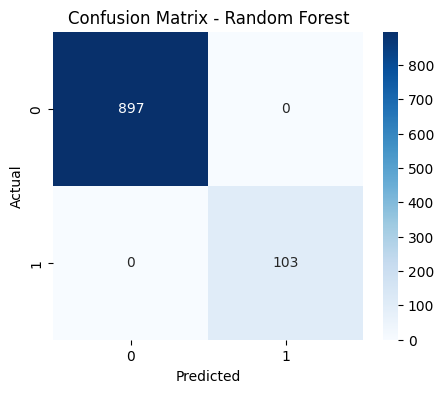

In [10]:
best_model_pred = y_pred_rf  # assuming RF performs better

cm = confusion_matrix(y_test, best_model_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**11. Feature Importance**

In [11]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False)

,0
Backlogs,0.251125
Technical_Score,0.242374
Aptitude_Score,0.239450
CGPA,0.230067
Communication_Score,0.020815
Internships,0.008099
Certifications,0.008071


**12. Model Selection Summary -**

• Random Forest outperformed Logistic Regression across F1 and ROC-AUC.

• Tree-based modeling captured non-linear relationships among academic indicators.

• Backlogs and Technical Score emerged as key employability predictors.

• Selected Random Forest as primary production candidate.